In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/coordinates/chemfiles.py:59: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  MIN_CHEMFILES_VERSION = LooseVersion("0.9")


In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = sorted(glob.glob("huNumbering/*t5a*/"))

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:404"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
    
    
    
v3s=[]
v3strings=[]
combinedLoopString="resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v3s.append(sub)        
    v3strings.append(sub2)
    
    
    
v123s=[]
v123strings=[]
combinedLoopString="resid 324:349 or resid 380:400 or resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v123s.append(sub)        
    v123strings.append(sub2)    

/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/topology/base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/core/selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details a

In [3]:
systemFolders

['huNumbering/rht5a/', 'huNumbering/t5a/', 'huNumbering/t5ar332p/']

In [4]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [5]:

dists = getPairwiseDists(systems,v123s,v123strings,stride = 1,EQPOINT=EQPOINT)




In [6]:
#save("allpcadists-V2-CApairwise.npy",dists)
#dists=load("allpcadists-V1-CApairwise.npy")

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

In [7]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

Text(0.5, 0, 'PC1')

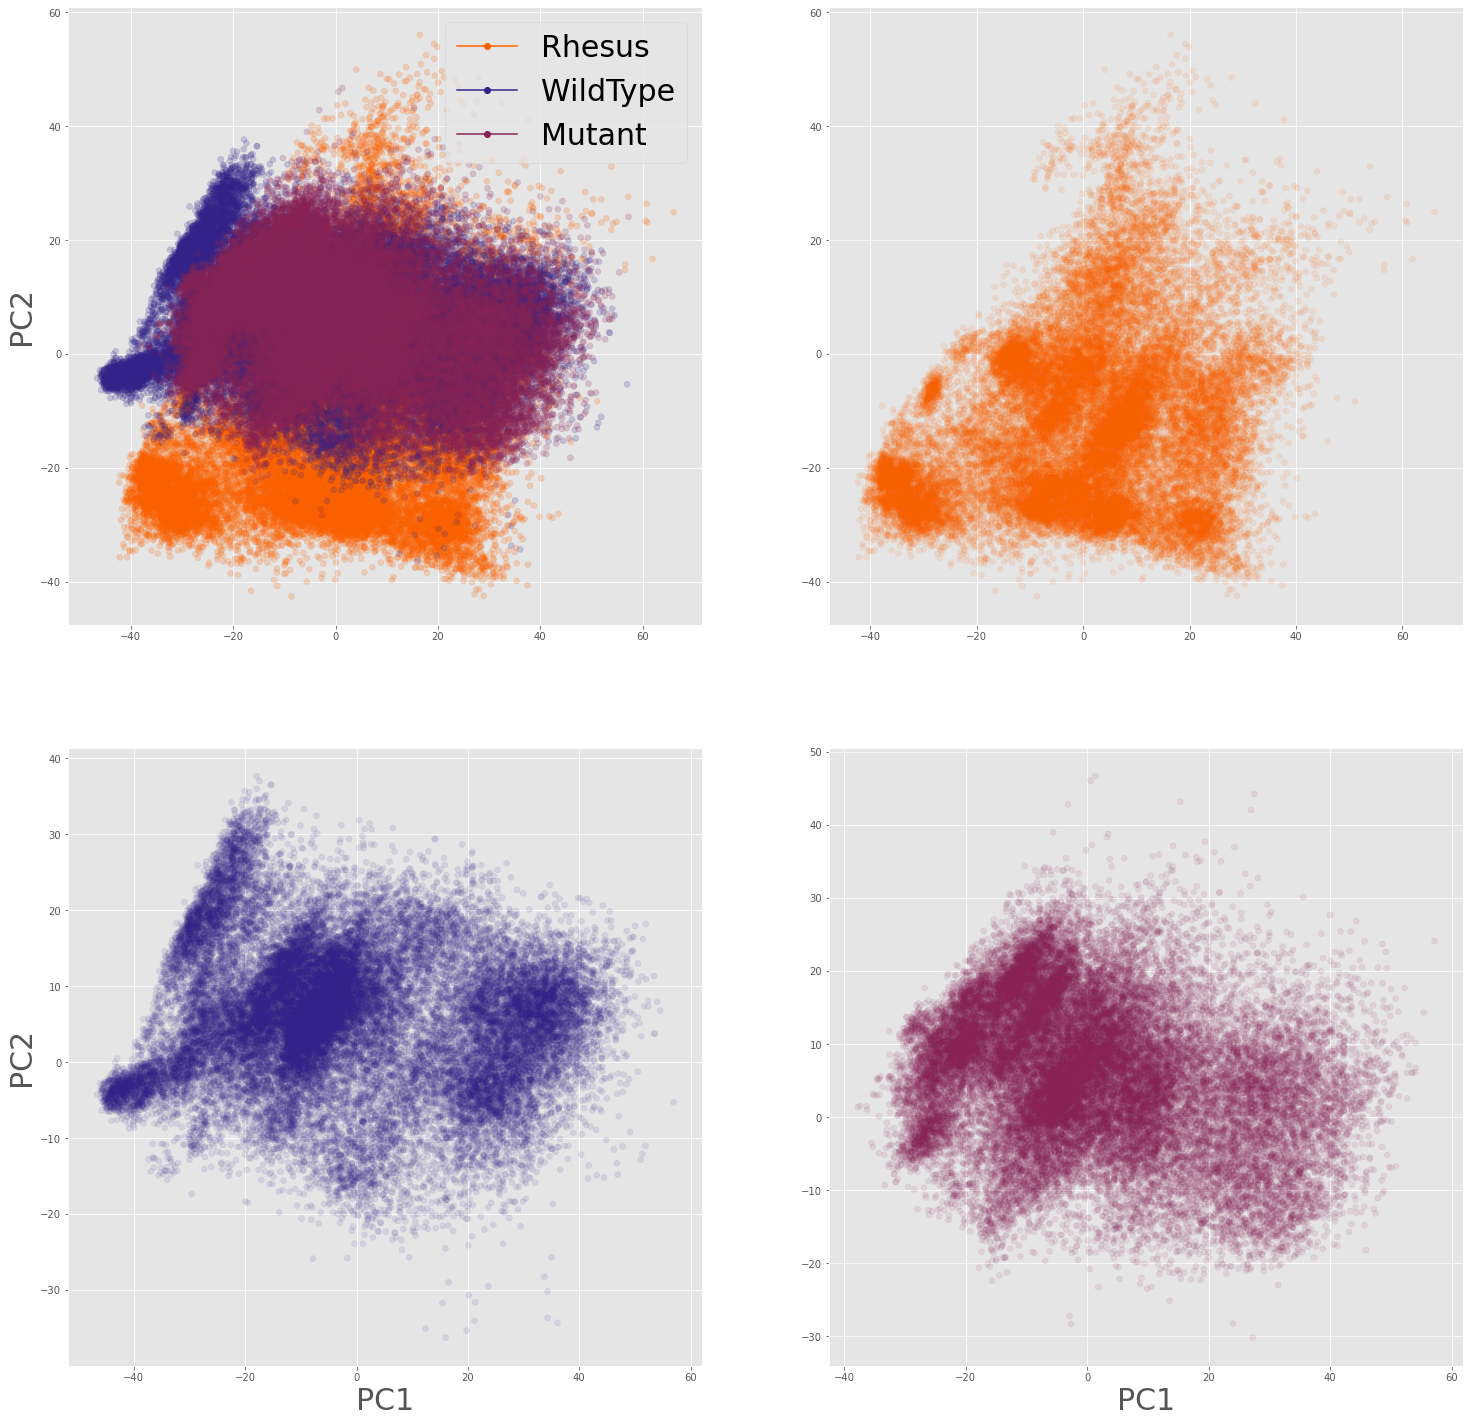

In [8]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-18,25)
#xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],color = pca_colours[:int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)

subplot(2,2,3)
scatter(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],color = pca_colours[int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],color = pca_colours[2*int(len(pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)


In [9]:
max(pcaPoints[0])

66.01277402804794

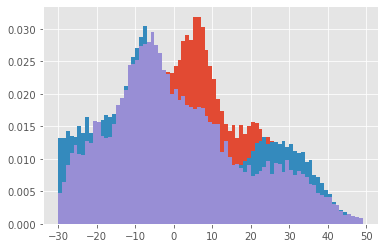

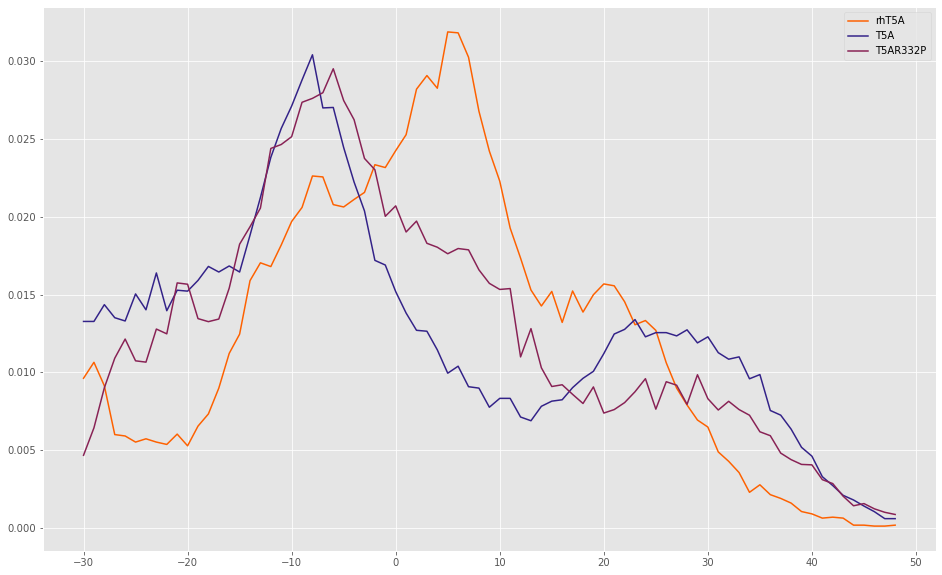

In [10]:
binrange = arange(-30,50,1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
systempc1s=[]
systempc1s.append(pcaPoints[0][:int(len(pcaPoints[0])/3)])
systempc1s.append(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)])
systempc1s.append(pcaPoints[0][2*int(len(pcaPoints[0])/3):])

    
pc1hists=[]
for i in range(len(systempc1s)):
    a = hist(systempc1s[i],bins = binrange,density = True)[0]
    pc1hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc1hists)):
    plot(binrange[:-1],pc1hists[i],color = threeColor[i],label = system_names[i])
    
legend()





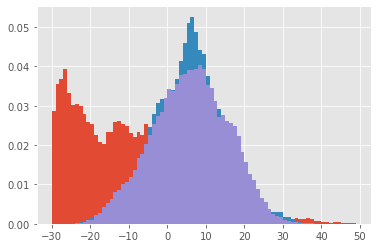

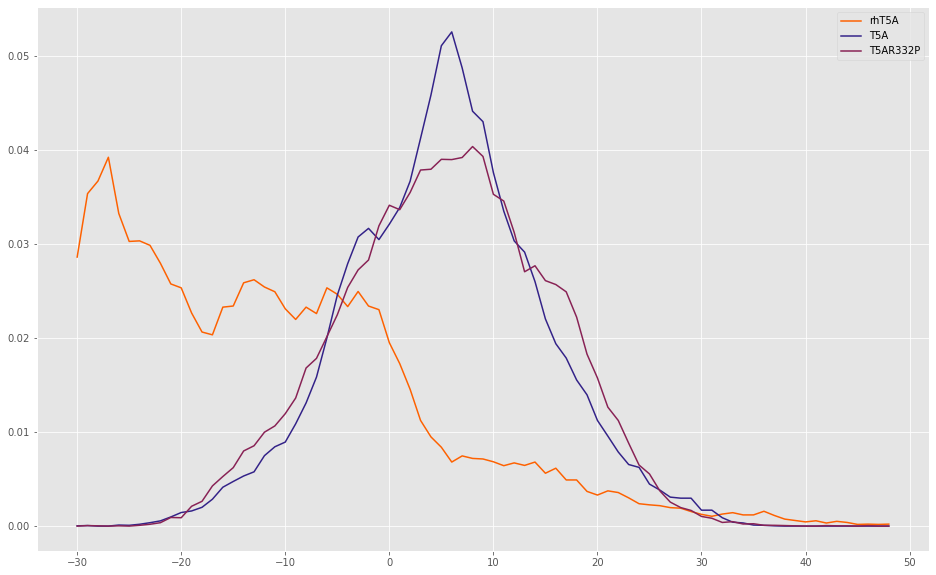

In [11]:
binrange = arange(-30,50,1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
system_pc2s=[]
system_pc2s.append(pcaPoints[1][:int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][int(len(pcaPoints[1])/3):2*int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][2*int(len(pcaPoints[1])/3):])

    
pc2hists=[]
for i in range(len(system_pc2s)):
    a = hist(system_pc2s[i],bins = binrange,density = True)[0]
    pc2hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc2hists)):
    plot(binrange[:-1],pc2hists[i],color = threeColor[i],label = system_names[i])
    
legend()





/home/liam/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/liam/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/liam/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 49.99999999999995, 'PC1')

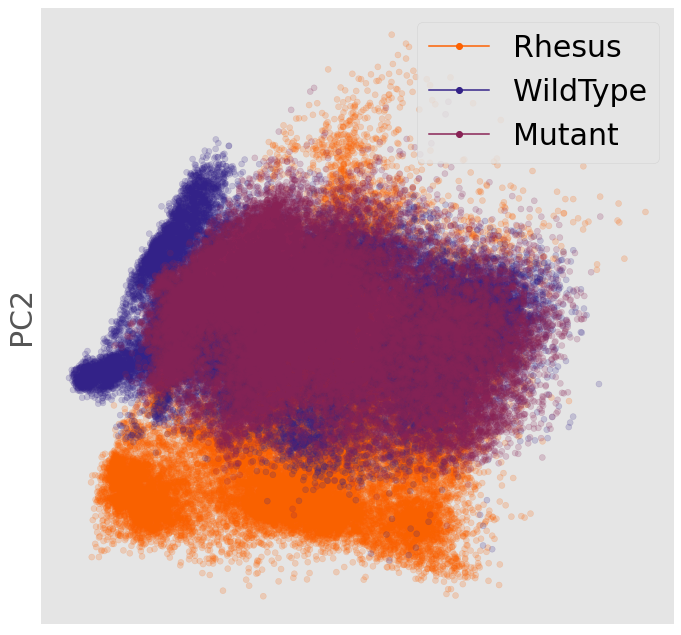

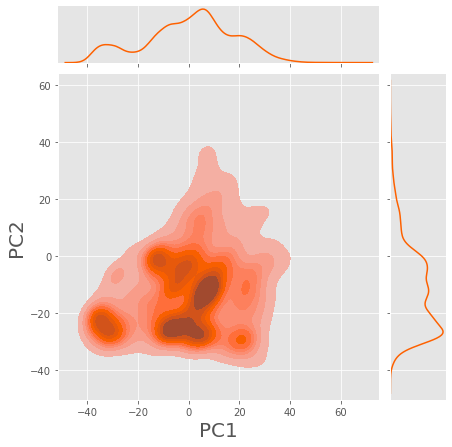

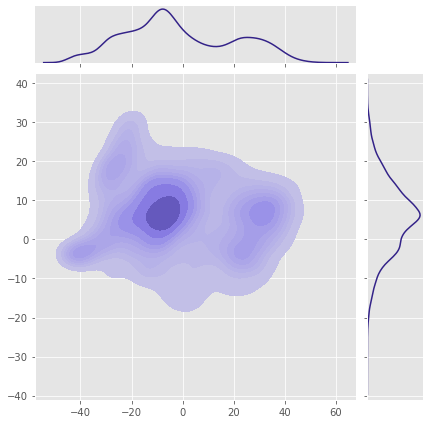

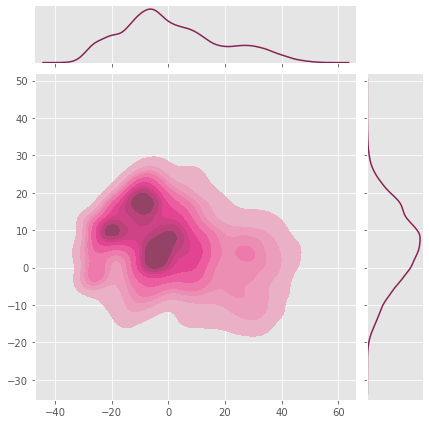

In [12]:
style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-20,45)
#xlim(-20,50)
xticks([])
yticks([])


h=sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0])
h.set_axis_labels('PC1', 'PC2', fontsize=20)
h.set
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
#
sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)


/home/liam/anaconda3/lib/python3.9/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/home/liam/anaconda3/lib/python3.9/site-packages/seaborn/distributions.py:1210: UserWarning: The following kwargs were not used by contour: 'xlabel'
  cset = contour_func(


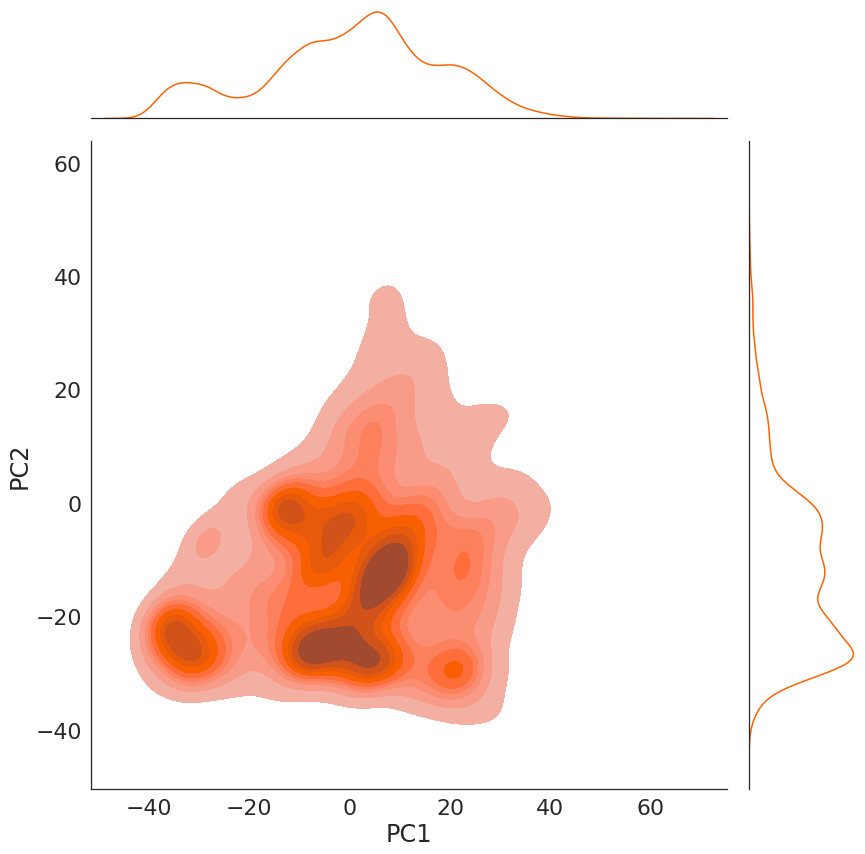

In [13]:
sns.set(font_scale=2,style = "white",rc={"axes.spines.right": False, "axes.spines.top":False})
fig = sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0],xlabel = "PC1",height = 12)

fig.set_axis_labels('PC1','PC2')


In [80]:
array(transformed_dists)[0][0][65].shape

(3, 9, 4001, 2)

In [133]:
db1.labels_

array([-1, -1, -1, ..., -1, -1, -1])

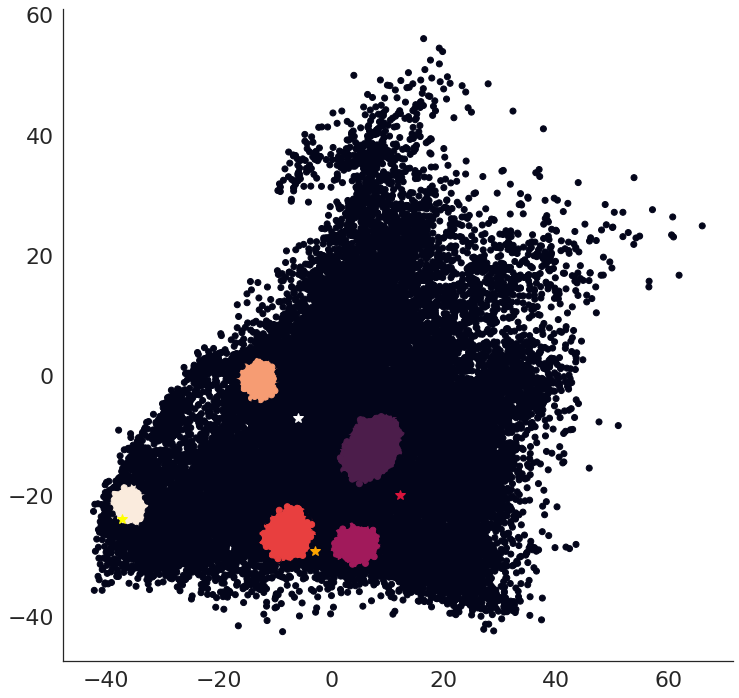

In [157]:
from sklearn.cluster import DBSCAN

#db1 = DBSCAN(eps=.991,min_samples = 127).fit(array(transformed_dists[0]).reshape(-1,2)) # this gives 4 clusters
db1 = DBSCAN(eps=2.3,min_samples = 500).fit(array(transformed_dists[0]).reshape(-1,2))
figure(figsize = (12,12))
plot(array(transformed_dists)[0][0][65][0],array(transformed_dists)[0][0][65][1],"*",color = "crimson",ms = 10)
plot(array(transformed_dists)[0][0][453][0],array(transformed_dists)[0][0][453][1],"*",color = "orange",ms = 10)
plot(array(transformed_dists)[0][1][223][0],array(transformed_dists)[0][1][223][1],"*",color = "yellow",ms = 10)
plot(array(transformed_dists)[0][1][391][0],array(transformed_dists)[0][1][391][1],"*",color = "white",ms = 10)
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)


In [163]:
where(db1.labels_.reshape(9,4001)==2)

(array([0, 0, 0, ..., 8, 8, 8]), array([447, 454, 590, ..., 955, 956, 980]))

In [164]:
db1.labels_.reshape(9,4001)[1][223]

4

In [169]:
for i in range(len(where(db1.labels_.reshape(9,4001) == 4)[0])):
    print(where(db1.labels_.reshape(9,4001) == 4)[0][i],where(db1.labels_.reshape(9,4001) == 4)[1][i])
    with MDAnalysis.Writer(f"v123_pdb_clusters/5State/State4/state4_trj{where(db1.labels_.reshape(9,4001) == 4)[0][i]}_frame{where(db1.labels_.reshape(9,4001) == 4)[1][i]}.pdb") as W:
        tu=systems[0][where(db1.labels_.reshape(9,4001) == 4)[0][i]]
        tu.trajectory[where(db1.labels_.reshape(9,4001) == 4)[1][i]]
        W.write(tu.select_atoms("protein"))

1 220
1 221
1 222


/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'altLocs' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'icodes' Using default value of ' '
  warnings.warn("Found no information for attr: '{}'"
/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'occupancies' Using default value of '1.0'
  warnings.warn("Found no information for attr: '{}'"
/home/liam/anaconda3/lib/python3.9/site-packages/MDAnalysis/coordinates/PDB.py:1026: UserWarning: Found no information for attr: 'tempfactors' Using default value of '0.0'
  warnings.warn("Found no information for attr: '{}'"


1 223
1 225
1 226
1 227
1 228
1 229
1 230
1 259
1 261
2 2440
2 2443
2 2444
2 2450
2 2452
2 2454
2 2505
2 2506
2 2507
2 2509
2 2546
2 2589
2 2614
2 2615
2 2617
2 2618
2 2620
2 2621
2 2622
2 2623
2 2624
2 2625
2 2626
2 2627
2 2633
2 2634
2 2641
2 2648
2 2652
2 2653
2 2655
2 2656
2 2657
2 2658
2 2659
2 2660
2 2661
2 2662
2 2663
2 2664
2 2669
2 2683
2 2684
2 2685
2 2692
2 2694
2 2695
2 2697
2 2699
2 2700
2 2701
2 2702
2 2703
2 2704
2 2705
2 2706
2 2707
2 2708
2 2709
2 2710
2 2711
2 2713
2 2714
2 2716
2 2718
2 2719
2 2720
2 2722
2 2723
2 2724
2 2725
2 2729
2 2731
2 2741
2 2745
2 2748
2 2749
2 2755
2 2758
2 2759
2 2761
2 2762
2 2763
2 2764
2 2765
2 2766
2 2767
2 2769
2 2770
2 2771
2 2772
2 2774
2 2775
2 2776
2 2779
2 2780
2 2781
2 2782
2 2784
2 2785
2 2786
2 2788
2 2789
2 2790
2 2807
2 2818
2 2819
2 2820
2 2821
2 2822
2 2824
2 2825
2 2826
2 2827
2 2828
2 2830
2 2831
2 2832
2 2833
2 2834
2 2835
2 2836
2 2839
2 2840
2 2841
2 2843
2 2844
2 2845
2 2846
2 2851
2 2852
2 2853
2 2854
2 2855
2 2856
2

In [34]:
from sklearn.cluster import DBSCAN

#db1 = DBSCAN(eps=.991,min_samples = 127).fit(array(transformed_dists[0]).reshape(-1,2)) # this gives 4 clusters
db1 = DBSCAN(eps=.8,min_samples = 60).fit(array(transformed_dists[0]).reshape(-1,2))
figure(figsize = (20,20))
plot(array(transformed_dists)[0][0][65][0],array(transformed_dists)[0][0][65][1],"*",color = "crimson",ms = 10)
plot(array(transformed_dists)[0][0][453][0],array(transformed_dists)[0][0][453][1],"*",color = "orange",ms = 10)
plot(array(transformed_dists)[0][1][223][0],array(transformed_dists)[0][1][223][1],"*",color = "yellow",ms = 10)
plot(array(transformed_dists)[0][1][391][0],array(transformed_dists)[0][1][391][1],"*",color = "white",ms = 10)
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = db1.labels_)






#colordict = {
#    -1:"black",
#    0:"crimson",
#    1:"darkorange",
#    2:"yellow",
#    3:"white"
#    
#}
#clusterColours=[]
#for i in range(len(db1.labels_)):
#    
#    clusterColours.append(colordict[db1.labels_[i]])
#
#
#
#figure(figsize = (12,12))
#scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours)
#
#
#xlabel("PC1",fontsize = 25)
#ylabel("PC2",fontsize = 25)
#
#

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32,
       33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49,
       50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66,
       67, 68, 69, 70, 71, 72, 73])

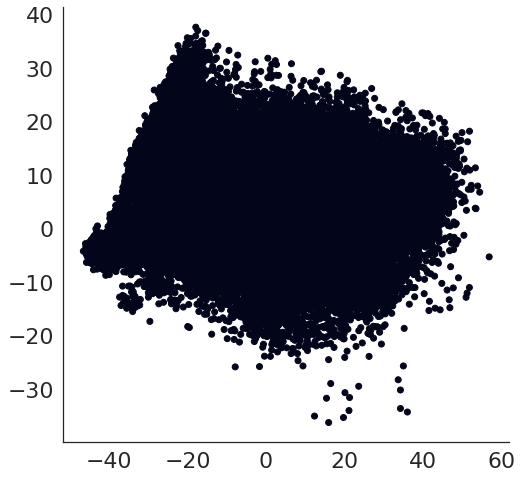

In [15]:



db2 = DBSCAN(eps=.7,min_samples = 175).fit(array(transformed_dists[1]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[1]).reshape(-1,2).T[0],array(transformed_dists[1]).reshape(-1,2).T[1],c = db2.labels_)


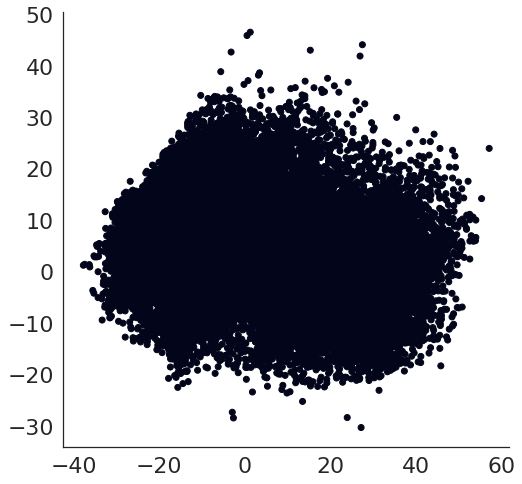

In [16]:
db3 = DBSCAN(eps=.7,min_samples = 175).fit(array(transformed_dists[2]).reshape(-1,2))
figure(figsize = (8,8))
scatter(array(transformed_dists[2]).reshape(-1,2).T[0],array(transformed_dists[2]).reshape(-1,2).T[1],c = db3.labels_)


In [61]:
trj_frame_db1_labels = db1.labels_.reshape(9,4001)
trj_frame_db2_labels = db2.labels_.reshape(9,4001)
trj_frame_db3_labels = db3.labels_.reshape(9,4001)



#Rhesus
print("TRJ",where(trj_frame_db1_labels == 0)[0][0],"Frame",where(trj_frame_db1_labels == 0)[1][0])
print("TRJ",where(trj_frame_db1_labels == 1)[0][0],"Frame",where(trj_frame_db1_labels == 1)[1][0])
print("TRJ",where(trj_frame_db1_labels == 2)[0][0],"Frame",where(trj_frame_db1_labels == 2)[1][0])
print("TRJ",where(trj_frame_db1_labels == 3)[0][0],"Frame",where(trj_frame_db1_labels == 3)[1][0])


TRJ 0 Frame 63
TRJ 1 Frame 89
TRJ 2 Frame 2617
TRJ 1 Frame 3411


In [75]:
for i in range(len(where(trj_frame_db1_labels == 0)[0])):
    print(where(trj_frame_db1_labels == 0)[0][i],where(trj_frame_db1_labels == 0)[1][i])
    with MDAnalysis.Writer(f"v123_pdb_clusters/state1_trj{where(trj_frame_db1_labels == 0)[0][i]}_frame{where(trj_frame_db1_labels == 0)[1][i]}.pdb") as W:
        tu=systems[0][where(trj_frame_db1_labels == 0)[0][i]]
        tu.trajectory[where(trj_frame_db1_labels == 0)[1][i]]
        W.write(tu.select_atoms("protein"))


0 63
0 64
0 77
0 115
0 171
0 204
0 210
0 214
0 220
0 221
0 223
0 226
0 227
0 229
0 230
0 231
0 306
0 319
0 404
0 405
0 462
0 465
0 466
0 467
0 477
0 485
0 493
0 496
0 497
0 498
0 504
0 511
0 512
0 521
0 526
0 540
0 541
0 555
0 557
0 599
0 627
0 642
0 644
0 654
0 656
0 676
0 679
0 716
0 724
0 725
0 726
0 731
0 736
0 738
0 743
0 746
0 748
0 753
0 755
0 757
0 761
0 766
0 768
0 773
0 776
0 782
0 784
0 787
0 806
0 809
0 811
0 813
0 815
0 818
0 820
0 826
0 828
0 835
0 836
0 837
0 844
0 850
0 859
0 865
0 866
0 873
0 878
0 879
0 912
0 915
0 916
0 917
0 935
0 943
0 949
0 953
0 954
0 955
0 957
0 961
0 985
0 990
0 993
0 995
0 996
0 997
0 998
0 999
0 1000
0 1001
0 1002
0 1003
0 1004
0 1005
0 1006
0 1008
0 1017
0 1022
0 1025
0 1026
0 1029
0 1030
0 1035
0 1037
0 1038
0 1073
0 1074
0 1076
0 1077
0 1080
0 1081
0 1083
0 1094
0 1096
0 1115
0 1117
0 1120
0 1124
0 1126
0 1133
0 1135
0 1137
0 1138
0 1139
0 1143
0 1145
0 1146
0 1147
0 1150
0 1153
0 1155
0 1158
0 1159
0 1160
0 1163
0 1164
0 1167
0 1168
0 116

0 3921
0 3922
0 3923
0 3924
0 3925
0 3926
0 3927
0 3928
0 3929
0 3930
0 3931
0 3932
0 3934
0 3935
0 3936
0 3938
0 3940
0 3942
0 3943
0 3944
0 3945
0 3946
0 3950
0 3951
0 3952
0 3953
0 3954
0 3956
0 3961
0 3962
0 3963
0 3964
0 3965
0 3966
0 3967
0 3968
0 3969
0 3970
0 3971
0 3972
0 3973
0 3974
0 3975
0 3977
0 3978
0 3980
0 3982
0 3983
0 3984
0 3986
0 3987
0 3988
0 3989
0 3990
0 3991
0 3992
0 3993
0 3996
1 393
1 471
1 480
1 481
1 577
1 582
1 584
1 741
1 749
1 756
1 771
1 862
1 914
1 916
1 949
1 950
1 951
1 960
1 961
1 963
1 964
1 994
1 999
1 1000
1 1004
1 1006
1 1038
1 1113
1 1428
1 1429
1 1430
1 1433
1 1441
1 1450
1 1454
1 1461
1 2414
1 2418
1 2653
1 3588
1 3589
1 3591
1 3598
1 3599
2 1849
2 1863
2 1913
2 1965
2 1967
2 1971
2 1976
2 1979
2 2048
2 2049
2 2050
2 2059
2 2212
2 2317
2 2357
2 2375
3 212
3 249
3 251
3 254
3 255
3 256
3 259
3 260
3 265
3 269
3 274
3 275
3 339
3 365
3 366
3 414
3 446
3 447
3 479
3 521
3 547
3 596
3 610
3 667
3 672
3 678
3 825
3 898
3 902
3 1366
3 1369
3 1375
3 

In [76]:
for i in range(len(where(trj_frame_db1_labels == 1)[0])):
    print(where(trj_frame_db1_labels == 1)[0][i],where(trj_frame_db1_labels == 1)[1][i])
    with MDAnalysis.Writer(f"v123_pdb_clusters/State1/state2_trj{where(trj_frame_db1_labels == 1)[0][i]}_frame{where(trj_frame_db1_labels == 1)[1][i]}.pdb") as W:
        tu=systems[0][where(trj_frame_db1_labels == 1)[0][i]]
        tu.trajectory[where(trj_frame_db1_labels == 1)[1][i]]
        W.write(tu.select_atoms("protein"))


1 89
1 277
1 279
1 282
1 284
1 287
1 290
1 301
1 302
1 330
1 347
1 348
1 607
1 615
1 620
1 1052
1 1154
1 1375
1 3626
2 2
2 15
2 31
2 36
2 39
2 61
2 124
2 162
2 163
2 211
2 340
2 365
2 370
2 399
2 469
2 580
2 581
2 582
2 584
2 588
2 592
2 594
2 595
2 596
2 598
2 599
2 609
2 611
2 628
2 629
2 648
2 650
2 651
2 652
2 653
2 659
2 673
2 674
2 676
2 680
2 681
2 682
2 1903
2 1904
2 1916
2 1917
2 1920
2 1955
2 1984
2 2028
2 2088
2 2145
2 2164
2 2556
2 2582
2 2587
4 596
4 599
4 602
4 606
4 611
4 618
4 680
4 706
4 754
4 762
4 764
4 767
4 771
4 774
4 776
4 779
4 782
4 793
4 795
4 798
4 799
4 801
4 802
4 803
4 804
4 806
4 808
4 816
4 817
4 818
4 819
4 820
4 821
4 822
4 823
4 824
4 825
4 826
4 827
4 829
4 830
4 831
4 832
4 833
4 834
4 835
4 836
4 837
4 838
4 839
4 840
4 842
4 843
4 844
4 846
4 847
4 848
4 849
4 850
4 852
4 853
4 854
4 855
4 856
4 857
4 858
4 859
4 860
4 861
4 863
4 865
4 866
4 867
4 868
4 869
4 870
4 871
4 872
4 873
4 874
4 875
4 876
4 879
4 880
4 881
4 882
4 883
4 884
4 885
4 886


In [78]:
for i in range(len(where(trj_frame_db1_labels == 2)[0])):
    print(where(trj_frame_db1_labels == 2)[0][i],where(trj_frame_db1_labels == 2)[1][i])
    with MDAnalysis.Writer(f"v123_pdb_clusters/State2/state3_trj{where(trj_frame_db1_labels == 2)[0][i]}_frame{where(trj_frame_db1_labels == 2)[1][i]}.pdb") as W:
        tu=systems[0][where(trj_frame_db1_labels == 2)[0][i]]
        tu.trajectory[where(trj_frame_db1_labels == 2)[1][i]]
        W.write(tu.select_atoms("protein"))


2 2617
2 2622
2 2626
2 2658
2 2664
2 2711
2 2839
2 2854
2 2863
2 2872
2 2873
2 3037
2 3086
2 3090
2 3091
2 3094
2 3095
2 3096
2 3097
2 3099
2 3100
2 3101
2 3102
2 3103
2 3105
2 3107
2 3112
2 3115
2 3123
2 3126
2 3127
2 3130
2 3131
2 3132
2 3139
2 3150
2 3154
2 3157
2 3234
2 3239
2 3240
2 3241
2 3243
2 3250
2 3251
2 3252
2 3264
2 3268
2 3272
2 3273
2 3285
2 3286
2 3290
2 3291
2 3292
2 3293
2 3294
2 3309
2 3312
2 3315
2 3320
2 3321
2 3325
2 3346
2 3357
2 3358
2 3361
2 3362
2 3363
2 3368
2 3371
2 3372
2 3375
2 3382
2 3383
2 3401
2 3403
2 3433
2 3461
2 3504
2 3506
2 3509
2 3560
2 3562
2 3581
2 3707
2 3712
2 3719
2 3739
2 3766
2 3835
2 3847
2 3849
2 3867
2 3870
2 3884
2 3983
2 3998
7 142
7 143
7 145
7 146
7 178
7 185
7 192
7 227
7 231
7 232
7 1502
7 1547
7 1548
7 1558
7 1563
7 1564
7 1565
7 1569
7 1570
7 1571
7 1573
7 1578
7 1582
7 1587
7 1603
7 1609
7 1622
7 1636
7 1908


In [79]:
for i in range(len(where(trj_frame_db1_labels == 3)[0])):
    print(where(trj_frame_db1_labels == 3)[0][i],where(trj_frame_db1_labels == 3)[1][i])
    with MDAnalysis.Writer(f"v123_pdb_clusters/State3/state4_trj{where(trj_frame_db1_labels == 3)[0][i]}_frame{where(trj_frame_db1_labels == 3)[1][i]}.pdb") as W:
        tu=systems[0][where(trj_frame_db1_labels == 3)[0][i]]
        tu.trajectory[where(trj_frame_db1_labels == 3)[1][i]]
        W.write(tu.select_atoms("protein"))


1 3411
1 3414
1 3433
1 3491
5 117
5 204
5 330
5 669
5 700
5 705
5 708
5 711
5 848
5 850
5 903
5 905
5 1110
5 2241
5 2406
5 2455
5 2459
5 2461
5 2490
5 2491
5 2500
5 2505
5 2508
5 2594
5 2621
5 2623
5 2632
5 2636
5 2637
5 2639
5 2644
5 2651
5 2670
5 2724
5 2746
5 2748
5 2749
5 2781
5 2785
5 2976
5 2994
5 2996
5 3001
5 3009
5 3019
5 3020
5 3021
5 3022
5 3026
5 3027
5 3035
5 3042
5 3050
5 3051
5 3066
5 3073
5 3076
5 3081
5 3083
5 3085
5 3092
5 3093
5 3100
5 3110
5 3111
5 3114
5 3130
5 3133
5 3136
5 3140
5 3152
5 3156
5 3159
5 3165
5 3167
5 3168
5 3176
5 3177
5 3192
5 3197
5 3198
5 3200
5 3205
5 3206
5 3215
5 3217
5 3219
5 3220
5 3221
5 3222
5 3240
5 3244
5 3247
5 3269
5 3290
5 3429
5 3449
5 3512
5 3523
5 3580
5 3587
5 3593
5 3627
5 3657
5 3660
5 3662
5 3673
5 3675
5 3710
5 3713
5 3715
5 3730
5 3731
5 3738
5 3742
5 3748
5 3750
5 3751
5 3758
5 3759
5 3762
5 3764
5 3768
5 3772
5 3783
5 3789
5 3792
5 3795
5 3801
5 3807
5 3823
5 3826
5 3834
5 3839
5 3840
5 3843
5 3845
5 3856
5 3857
5 3859
5 38

In [ ]:



#WT
print("TRJ",where(trj_frame_db2_labels == 0)[0][0],where(trj_frame_db2_labels == 0)[1][0])


In [ ]:
#RF332P
print("TRJ",where(trj_frame_db3_labels == 0)[0][0],"Frame", where(trj_frame_db3_labels == 0)[1][0])
print("TRJ",where(trj_frame_db3_labels == 1)[0][0],"Frame", where(trj_frame_db3_labels == 1)[1][0])


In [ ]:
with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_1_trj0_frame65.pdb") as W:
    
    tu=systems[0][0]
    tu.trajectory[65]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_2_trj0_frame453.pdb") as W:
    
    tu=systems[0][0]
    tu.trajectory[453]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_3_trj1_frame223.pdb") as W:
    
    tu=systems[0][1]
    tu.trajectory[223]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("state_dbscan_outputs_rhesus_3loopstate_4_trj1_frame391.pdb") as W:
    
    tu=systems[0][1]
    tu.trajectory[391]
    W.write(tu.select_atoms("protein"))

In [ ]:
with MDAnalysis.Writer("state_dbscan_outputs_wt_3loopstate_1_trj0_frame13.pdb") as W:
    
    tu=systems[1][0]
    tu.trajectory[13]
    W.write(tu.select_atoms("protein"))

In [ ]:
with MDAnalysis.Writer("state_dbscan_outputs_r332p_3loopstate_1_trj0_frame31.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[31]
    W.write(tu.select_atoms("protein"))
    
with MDAnalysis.Writer("state_dbscan_outputs_r332p_3loopstate_1_trj0_frame82.pdb") as W:
    
    tu=systems[2][0]
    tu.trajectory[82]
    W.write(tu.select_atoms("protein"))